# 04 · Multivariate — Correlation, PCA, VAR, Granger, Cointegration & Pairs

## Part 4 — Multivariate Time Series

Parts 1–3 looked at one variable at a time. Real systems move **together**: stocks share a
market, sectors co-move, and some pairs are tethered by a long-run equilibrium. This notebook is
about the *joint* structure.

| # | tool | question |
|---|---|---|
| 2 | **Correlation + clustering** | which series move together? do sectors emerge on their own? |
| 3 | **PCA factor model** | is there a single 'market' driving everything? (CAPM's PC1) |
| 4 | **VAR** | can the past of *all* series predict each one? |
| 5 | **Granger causality** | does series A's past help predict series B (lead/lag)? |
| 6 | **Cointegration** | are two drifting prices tied by a stationary spread? |
| 7 | **Pairs trading** | …and how that spread becomes a mean-reversion strategy |

**Data:** a panel of **12 S&P 500 large caps in 6 same-sector pairs** (Tech AAPL/MSFT, Banks
JPM/BAC, Energy XOM/CVX, Staples KO/PEP, Health JNJ/PFE, Retail WMT/TGT), daily 2013–2018. The
pairs are deliberate cointegration candidates. Stationary inputs (returns) drive correlation/
PCA/VAR/Granger; price **levels** drive cointegration.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd()
ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

from src import multivariate as mv
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import VECM
import seaborn as sns

px = data.load_stock_panel()            # 12 large caps, daily close, 2013-2018
ret = data.stock_log_returns()          # daily log returns (stationary)
SECTORS = data.SECTORS
print("panel:", px.shape, "| returns:", ret.shape, "|", px.index.min().date(), "->", px.index.max().date())


setup ok | numpy 2.1.3 | pandas 2.3.3


panel: (1259, 12) | returns: (1258, 12) | 2013-02-08 -> 2018-02-07


### 2. Correlation structure — and letting the sectors emerge

The return correlation matrix says who moves with whom. If we **reorder** it by hierarchical
clustering (group by similarity), the sector blocks should appear on the diagonal *without us
telling the algorithm what the sectors are* — a sanity check that the structure is real.

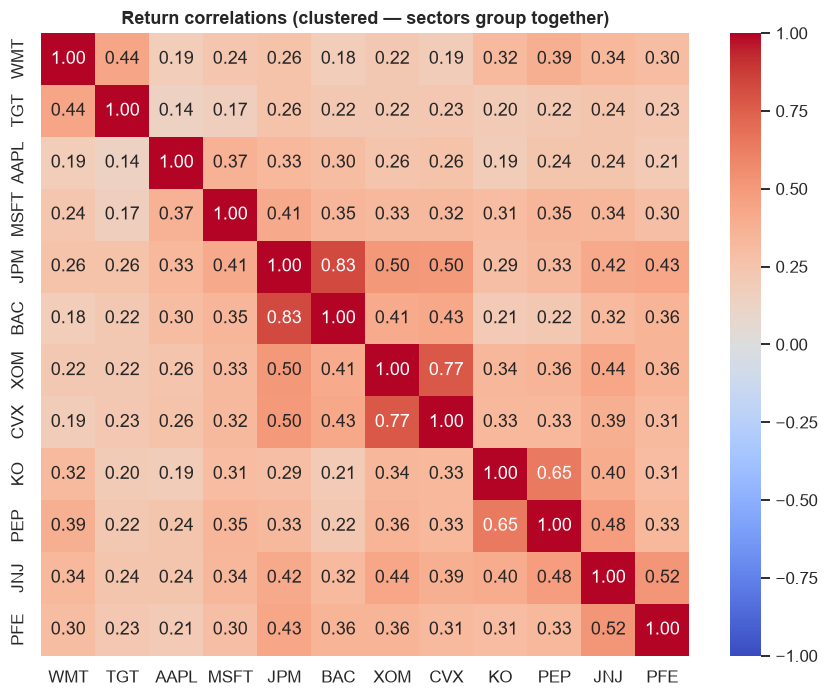

average pairwise return correlation: 0.33
Everything is positively correlated -> a common factor is at work (next section).


In [2]:
corr = mv.corr_heatmap(ret, fname="p4_corr_clustered.png")
plt.show()
off_diag = corr.where(~np.eye(len(corr), dtype=bool))
print("average pairwise return correlation: %.2f" % off_diag.stack().mean())
print("Everything is positively correlated -> a common factor is at work (next section).")

Two facts jump out: **every** pair is positively correlated (no diversification escapes the
market), and the clustering recovers the **sector pairs** (KO–PEP, JPM–BAC, XOM–CVX…) as the
tightest blocks. That non-zero *average* correlation is the fingerprint of a shared driver.

### 3. PCA — extracting the market factor

If everything co-moves, a few **latent factors** should explain most of the variance. PCA finds
the orthogonal directions of maximum variance:

- **PC1** almost always has **all-positive loadings** — it is the *market factor* (the day the
  whole market is up/down). Its share of variance measures how 'one-directional' the market is.
- **PC2, PC3…** typically capture **sector / style tilts** (e.g. Energy vs the rest).

This is the empirical seed of factor models (CAPM, Fama–French).

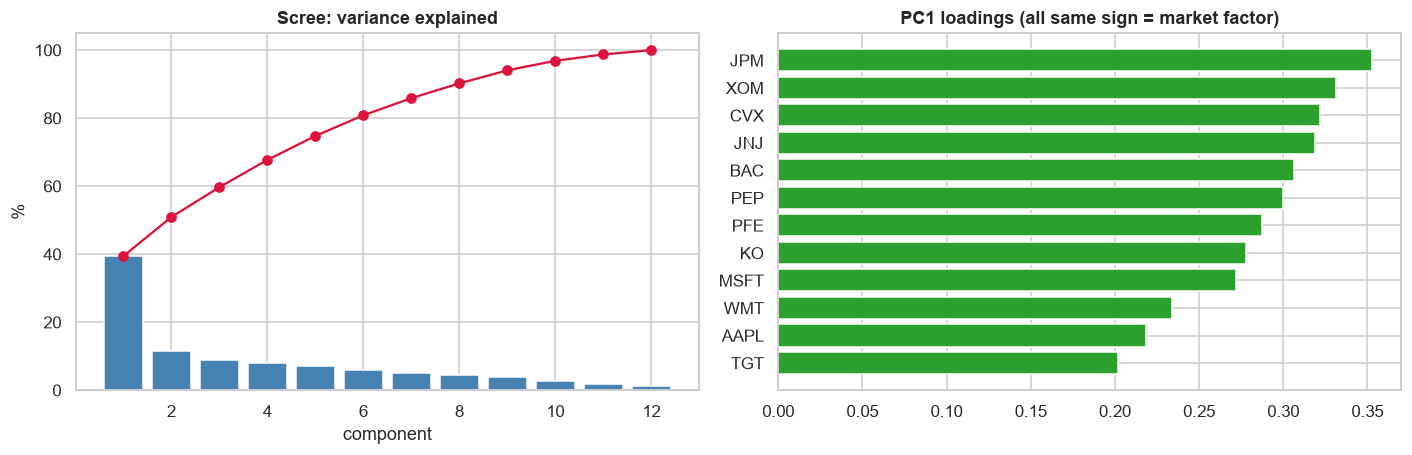

PC1 = 39.4% of variance (the market). PC1+PC2 = 50.9%.


In [3]:
pca, evr, loadings, scores = mv.pca_factors(ret)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
ax[0].bar(range(1, len(evr)+1), evr.values*100, color="steelblue")
ax[0].plot(range(1, len(evr)+1), evr.cumsum().values*100, "o-", color="crimson")
ax[0].set_title("Scree: variance explained"); ax[0].set_xlabel("component"); ax[0].set_ylabel("%")
order = loadings["PC1"].sort_values().index
ax[1].barh(order, loadings.loc[order, "PC1"], color=["tab:green" if v>0 else "tab:red" for v in loadings.loc[order,"PC1"]])
ax[1].set_title("PC1 loadings (all same sign = market factor)")
fig.tight_layout(); eda.savefig(fig, "p4_pca.png"); plt.show()
print("PC1 = %.1f%% of variance (the market). PC1+PC2 = %.1f%%." % (100*evr.iloc[0], 100*evr.iloc[:2].sum()))

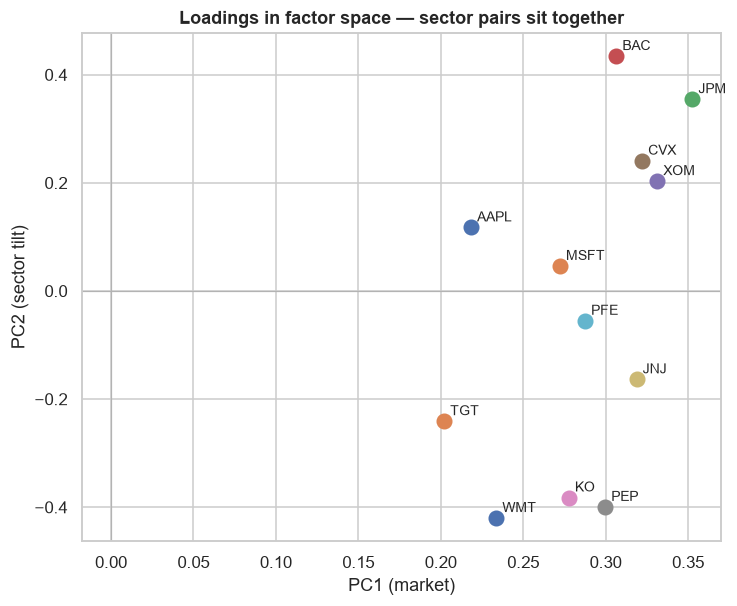

In [4]:
# PC2 vs PC1, by name: do sectors separate along later components?
fig, ax = plt.subplots(figsize=(7.5, 6))
for tk in loadings.index:
    ax.scatter(loadings.loc[tk,"PC1"], loadings.loc[tk,"PC2"], s=90)
    ax.annotate(f"{tk}", (loadings.loc[tk,"PC1"], loadings.loc[tk,"PC2"]), fontsize=9,
                xytext=(4,4), textcoords="offset points")
ax.axhline(0, color="0.7", lw=.8); ax.axvline(0, color="0.7", lw=.8)
ax.set_xlabel("PC1 (market)"); ax.set_ylabel("PC2 (sector tilt)")
ax.set_title("Loadings in factor space — sector pairs sit together")
eda.savefig(fig, "p4_pca_biplot.png"); plt.show()

**PC1 ≈ 39% of all variance with uniformly positive loadings** is the market: one factor moves
every name. On **PC2** the names spread out by sector (the two energy stocks, the two banks, etc.
land near each other) — the latent factors line up with the economics, never having been told the
sectors.

### 4. VAR — vector autoregression

A **VAR(p)** regresses each series on `p` lags of *every* series (itself + the others), capturing
joint dynamics. It needs **stationary** inputs → we use returns. The lag order `p` is chosen by an
information criterion, just like ARIMA. We fit a small cross-sector system to keep it readable.

In [5]:
sub = ret[["AAPL", "JPM", "XOM", "KO"]]
sel = VAR(sub).select_order(10)
print("Lag order suggested by each criterion:")
print(pd.Series(sel.selected_orders).to_string())
p = max(1, sel.selected_orders["bic"])
var_res = VAR(sub).fit(p)
print(f"\nFitted VAR({p}). Example: is AAPL Granger-caused by the others (within the VAR)?")
print(var_res.test_causality("AAPL", ["JPM", "XOM", "KO"], kind="f").summary())

Lag order suggested by each criterion:
aic     0
bic     0
hqic    0
fpe     0

Fitted VAR(1). Example: is AAPL Granger-caused by the others (within the VAR)?
Granger causality F-test. H_0: ['JPM', 'XOM', 'KO'] do not Granger-cause AAPL. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
         1.732          2.607   0.158 (3, 5008)
-----------------------------------------------


C:\Users\parth\practice-eda\sp500-shiller\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\parth\practice-eda\sp500-shiller\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


### 5. Granger causality — does A's past help predict B?

A series **Granger-causes** another if its lags improve the forecast of the other *beyond* that
other's own lags. Crucial caveats:

- it is about **predictability, not true causation** (a common driver or a faster-reacting stock
  can produce it);
- both series must be **stationary** (returns), or you get spurious results.

We compute the full directed matrix of smallest p-values over lags 1–5.

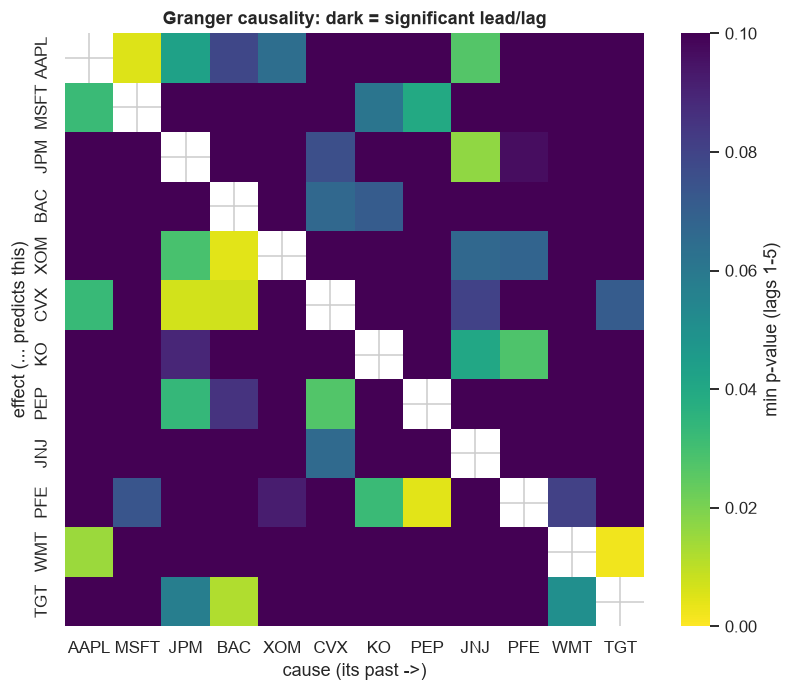

Strongest directed lead/lag links (p < 0.01), 'cause -> effect':
  TGT   -> WMT     p=0.0021
  PEP   -> PFE     p=0.0045
  BAC   -> XOM     p=0.0045
  MSFT  -> AAPL    p=0.0052
  JPM   -> CVX     p=0.0069
  BAC   -> CVX     p=0.0072


In [6]:
gm = mv.granger_matrix(ret, maxlag=5)
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(gm.astype(float), cmap="viridis_r", vmin=0, vmax=0.1, ax=ax,
            cbar_kws={"label": "min p-value (lags 1-5)"})
ax.set_xlabel("cause (its past ->)"); ax.set_ylabel("effect (... predicts this)")
ax.set_title("Granger causality: dark = significant lead/lag")
eda.savefig(fig, "p4_granger.png"); plt.show()
sig = gm.stack().sort_values()
sig = sig[sig < 0.01]
print("Strongest directed lead/lag links (p < 0.01), 'cause -> effect':")
for (effect, cause), pv in sig.items():
    print(f"  {cause:5s} -> {effect:5s}   p={pv:.4f}")

The matrix is **asymmetric** — that is the whole point. A handful of names lead others
(e.g. larger/faster stocks predicting their sector peers a day later). But remember: this is
*predictive* lead/lag, often driven by how fast each stock absorbs common news — not proof that
one company moves another.

### 6. Cointegration — drifting together

Correlation is about *co-movement of returns*. **Cointegration** is deeper and about *levels*:
two prices are each non-stationary **I(1)** (random walks), yet a linear combination of them is
**stationary** — they are tied by a long-run equilibrium and never wander too far apart.

Why it matters: regressing one trending price on another invites **spurious regression** (huge R²,
zero meaning). Cointegration is the *legitimate* exception — and the foundation of pairs trading.

First the trap: two stocks can be highly correlated in levels yet **not** cointegrated.

AAPL vs KO: level correlation = 0.66 (looks related!)
...but Engle-Granger coint p = 0.335  -> NOT cointegrated (spread wanders).


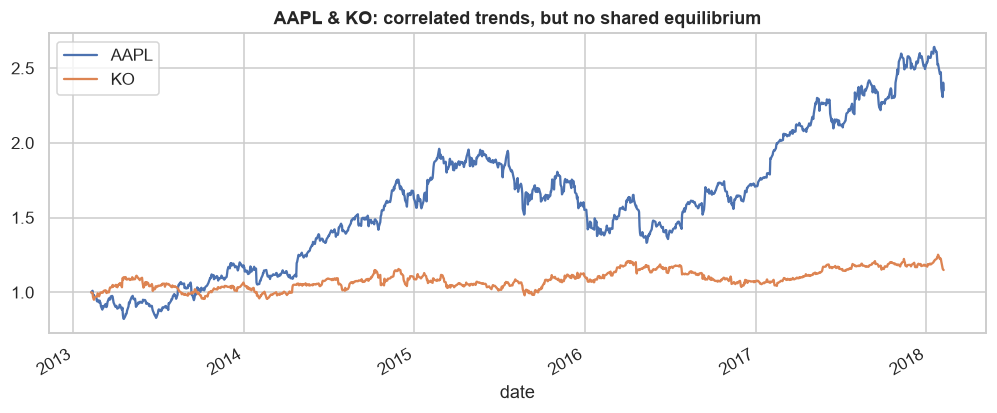

In [7]:
a, b = "AAPL", "KO"
print(f"{a} vs {b}: level correlation = %.2f (looks related!)" % px[a].corr(px[b]))
eg_bad = mv.engle_granger(px[a], px[b])
print(f"...but Engle-Granger coint p = {eg_bad['coint_p']:.3f}  -> NOT cointegrated (spread wanders).")
fig, ax = plt.subplots(figsize=(11,4))
(px[[a,b]]/px[[a,b]].iloc[0]).plot(ax=ax)  # normalised to 1 at start
ax.set_title(f"{a} & {b}: correlated trends, but no shared equilibrium"); eda.savefig(fig,"p4_spurious.png"); plt.show()

Now scan all six **same-sector** pairs with the **Engle–Granger** two-step (OLS hedge ratio →
test the spread for stationarity):

In [8]:
pairs = [("AAPL","MSFT"),("JPM","BAC"),("XOM","CVX"),("KO","PEP"),("JNJ","PFE"),("WMT","TGT")]
scan = mv.cointegration_scan(px, pairs)
print(scan.to_string())
best = tuple(scan.iloc[0]["pair"].split("-"))
print(f"\nOnly {best[0]}-{best[1]} clears the bar (coint p < 0.05). Cointegration is RARE -- most")
print("same-sector pairs are not tethered, which is exactly why a real signal is valuable.")

        pair  coint_p    beta  spread_adf_p
0     KO-PEP   0.0253  0.1644        0.0060
1    JNJ-PFE   0.4346  4.6112        0.2139
2    JPM-BAC   0.4367  3.3269        0.2153
3  AAPL-MSFT   0.5955  1.8510        0.3473
4    XOM-CVX   0.8346  0.3940        0.6382
5    WMT-TGT   0.9639 -0.1743        0.8914

Only KO-PEP clears the bar (coint p < 0.05). Cointegration is RARE -- most
same-sector pairs are not tethered, which is exactly why a real signal is valuable.


In [9]:
# Confirm with the Johansen test (multivariate, rank-based).
print(f"Johansen trace test on {best}:")
print(mv.johansen_summary(px[list(best)]).to_string(index=False))
print("\nTrace stat beats the 95% crit at r<=0 but not r<=1 -> exactly ONE cointegrating relation.")

Johansen trace test on ('KO', 'PEP'):
H0_rank<=r  trace_stat  crit_95%  cointegrated
      r<=0      17.683    15.494          True
      r<=1       2.974     3.842         False

Trace stat beats the 95% crit at r<=0 but not r<=1 -> exactly ONE cointegrating relation.


### 7. Pairs trading — turning the spread into a signal

If KO and PEP are tied by a stationary spread, then when the spread stretches it should snap back.
The recipe:

1. **spread** = KO − β·PEP (β = the cointegrating hedge ratio).
2. **z-score** the spread. When `z > +2`: spread is rich → **short** KO / long PEP. When `z < −2`:
   → **long** KO / short PEP. Exit as `z → 0`.
3. A **VECM** formalises this: the *error-correction term* measures how fast each leg is pulled
   back toward equilibrium.

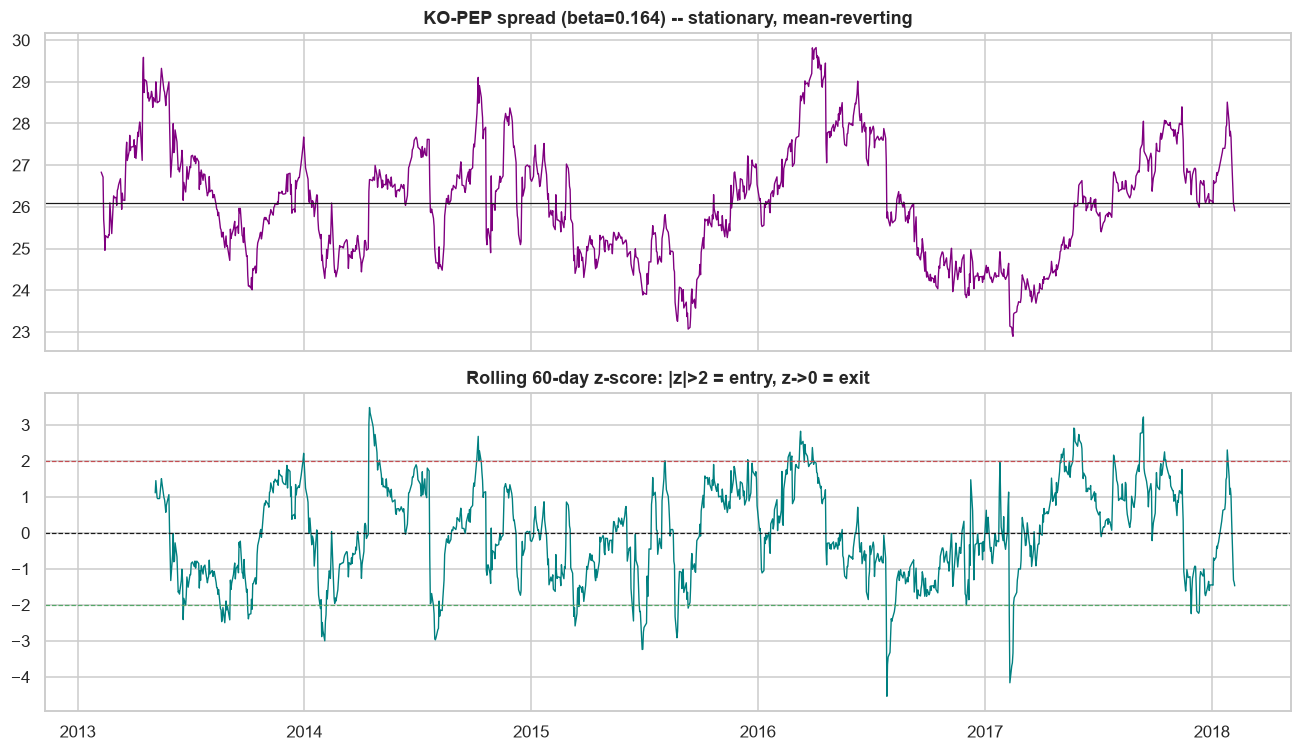

days with a live entry signal (|rolling z|>2): 131 of 1200


In [10]:
eg = mv.engle_granger(px[best[0]], px[best[1]])
spread = eg["spread"]
z_full = mv.zscore(spread)              # in-sample (illustrative)
z_roll = mv.zscore(spread, window=60)   # rolling (no look-ahead -> tradeable)
fig, ax = plt.subplots(2,1, figsize=(12,7), sharex=True)
ax[0].plot(spread.index, spread, color="purple", lw=.9); ax[0].axhline(spread.mean(), color="k", lw=.8)
ax[0].set_title(f"{best[0]}-{best[1]} spread (beta={eg['beta']:.3f}) -- stationary, mean-reverting")
ax[1].plot(z_roll.index, z_roll, color="teal", lw=.9)
for k,c in [(2,"r"),(-2,"g"),(0,"k")]: ax[1].axhline(k, color=c, ls="--", lw=.8)
ax[1].set_title("Rolling 60-day z-score: |z|>2 = entry, z->0 = exit")
fig.tight_layout(); eda.savefig(fig, "p4_pairs_spread.png"); plt.show()
print("days with a live entry signal (|rolling z|>2): %d of %d" % ((z_roll.abs()>2).sum(), z_roll.notna().sum()))

In [11]:
# VECM: the error-correction speeds (alpha). A negative alpha on the leg that is 'too high'
# means it gets pulled back down -> the mechanism behind the mean reversion.
vecm = VECM(px[list(best)], k_ar_diff=1, coint_rank=1, deterministic="ci").fit()
alpha = pd.Series(vecm.alpha.ravel(), index=best, name="adjustment speed (alpha)")
print("VECM error-correction speeds:"); print(alpha.round(4).to_string())
print("\nbeta (cointegrating vector):", np.round(vecm.beta.ravel(), 3))
print("At least one leg has a significant pull back to equilibrium -> the spread mean-reverts.")

VECM error-correction speeds:
KO    -0.0276
PEP   -0.0213

beta (cointegrating vector): [ 1.    -0.153]
At least one leg has a significant pull back to equilibrium -> the spread mean-reverts.


C:\Users\parth\practice-eda\sp500-shiller\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


**Caveat — this is the *mechanism*, not a backtest.** The full-sample z-score peeks at the
future; only the **rolling** z is tradeable. A real strategy also needs transaction costs, a
rolling re-estimate of β, and out-of-sample validation — which is exactly the **walk-forward
backtesting** we build in Part 6. And cointegration can *break* (a merger, a shock), so live pairs
must be re-tested continually.

### Takeaways

- Equity returns are **all positively correlated** — clustering recovers the sectors unsupervised.
- **PCA**: PC1 (~39%) is the **market factor** (all-positive loadings); later PCs are sector tilts.
  This is the empirical basis of CAPM / factor models.
- **VAR** models the joint dynamics of stationary series; **Granger causality** is an *asymmetric,
  predictive* lead/lag relation — *not* proof of causation, and only valid on stationary data.
- **Cointegration** is the legitimate exception to spurious regression: I(1) prices with a
  **stationary spread**. It is **rare** — only KO–PEP of six sector pairs — confirmed by both
  Engle–Granger and Johansen.
- That stationary spread is the engine of **pairs trading**; **VECM** describes how fast each leg
  error-corrects. The honest signal is the **rolling** z-score (no look-ahead).

**Next — Part 5 (ML / DL forecasting):** reframe forecasting as supervised learning, engineer
**leakage-safe** lag/rolling features (the `.shift(1)` discipline), and train gradient-boosted
trees (LightGBM) — then contrast the ML approach with the classical models from Part 3.